# Automated ML Pipeline for Abalone Age Prediction

## Project Overview
This project implements a complete machine learning pipeline using Amazon SageMaker Pipelines to predict the age of abalone (sea snails) based on physical measurements. Using the classic UCI Abalone dataset, we build a regression model that predicts the number of rings in an abalone's shell (a proxy for age) using physical characteristics like shell dimensions and various weight measurements. This presents an interesting regression challenge due to the complex relationships between features and the natural variability in biological data.

## Pipeline Architecture
The pipeline consists of four main stages:

1. **Preprocessing** (`preprocess.py`)
   - Handles missing data imputation
   - Performs feature scaling and encoding
   - Splits data into train/validation/test sets
   - Uses scikit-learn pipelines for transformations

2. **Training** (`train.py`)
   - Implements XGBoost regression model
   - Configures hyperparameters and training settings
   - Supports both CPU and GPU training
   - Includes early stopping with validation data

3. **Evaluation** (`evaluate.py`)
   - Calculates regression metrics (MSE)
   - Computes prediction standard deviation
   - Generates structured evaluation reports
   - Validates model performance

4. **Registration** (`register.py`)
   - Uploads evaluation metrics to S3
   - Creates model schema and metadata
   - Registers model in SageMaker registry
   - Sets deployment configurations

## Execution Flow
1. The pipeline starts by preprocessing the raw abalone dataset from S3
2. Preprocessed data feeds into the XGBoost training process
3. Trained model undergoes evaluation on test data
4. Upon successful evaluation, model is registered for deployment
5. All artifacts and metrics are tracked in the SageMaker registry

## Running the Pipeline
This notebook orchestrates the pipeline execution by:
- Setting up SageMaker session and roles
- Configuring pipeline parameters
- Triggering pipeline execution
- Monitoring progress and results

The pipeline ensures reproducibility and maintains a clear audit trail of the entire ML workflow.

In [ ]:
!pip install -r requirements.txt


### Step 2. Run the Amazon SageMaker Pipeline

In [ ]:
!python pipeline.py 

### Step 3. Observe Amazon SageMaker Pipeline execution

After running the above cell you will be able to see the execution of the SageMaker Pipeline into the Pipeline tab of SageMaker Studio.  An example execution is shown in the following figure:

!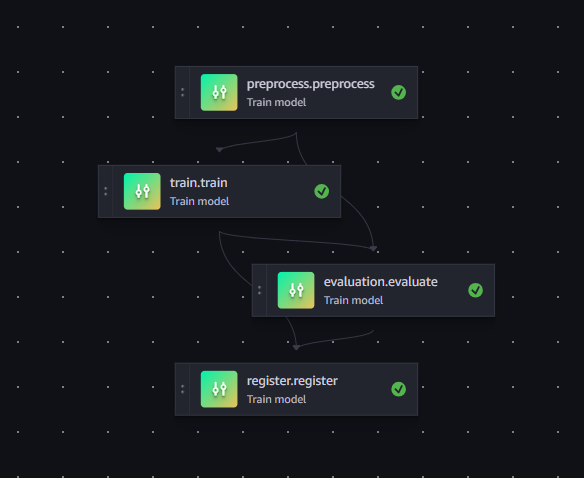



## Step 4. Observe the evaluation metrics 
After your pipeline completes successfully, run the next cell to obtain the evaluation metrics results.

In [ ]:
import sagemaker
from sagemaker import Session
import boto3
import json

# Get the clients
session = Session()
sm_client = session.sagemaker_client
s3_client = boto3.client('s3')

try:
    # Get pipeline executions
    response = sm_client.list_pipeline_executions(
        PipelineName="abalone-sm-pipeline-approved-on-event"
    )
    
    if 'PipelineExecutionSummaries' in response and response['PipelineExecutionSummaries']:
        latest_execution = response['PipelineExecutionSummaries'][0]
        pipeline_execution_id = latest_execution['PipelineExecutionArn'].split('/')[-1]
        
        # Get the default bucket
        bucket = session.default_bucket()
        
        # List objects in the evaluation-report directory
        response = s3_client.list_objects_v2(
            Bucket=bucket,
            Prefix=f"evaluation-report/"
        )
        
        # Get the most recent evaluation file
        if 'Contents' in response:
            latest_eval = max(response['Contents'], key=lambda x: x['LastModified'])
            
            # Get the evaluation report
            eval_obj = s3_client.get_object(
                Bucket=bucket,
                Key=latest_eval['Key']
            )
            
            eval_data = json.loads(eval_obj['Body'].read().decode('utf-8'))
            
            print("\nEvaluation Metrics:")
            mse = eval_data['regression_metrics']['mse']['value'] # 平均二乗誤差
            rmse = eval_data['regression_metrics']['rmse']['value'] # 二乗平均平方根誤差
            residual_std = eval_data['regression_metrics']['residual_std']['value'] # 残差の標準偏差
            print(f"MSE: {mse:.4f}")
            print(f"MSE: {rmse:.4f}")
            print(f"MSE: {residual_std:.4f}")
            
except Exception as e:
    print(f"Error occurred: {str(e)}")